# Incremental Aerodynamic Acceleration Residuals from Foxglove CSVs

This notebook analyzes incremental acceleration residuals to quantify aerodynamic effects during flight by comparing measured accelerations (from IMU) with thrust-only predictions.

## 1. Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from transforms3d.quaternions import quat2mat

pd.set_option("display.max_columns", None)
pd.set_option("display.width", None)

print("Libraries imported.")

Libraries imported.


## 2. Configuration

Set the data directory and physical parameters for the X-wing platform.

In [2]:
# Folder with all CSVs
data_dir = Path("/home/nebu/Documents/TUM/Masterarbeit/MasterTheses/logs/Circle/8mps_imu")
# data_dir = Path("/home/nebu/Documents/TUM/Masterarbeit/MasterTheses/logs/Circle/12mps_line")

# Physical parameters
mass = 2.5        # kg
g = 9.81          # m/s^2
n_motors = 4      # X-wing quad

print(f"Data directory: {data_dir}")
print(f"Mass: {mass} kg")
print(f"Number of motors: {n_motors}")

Data directory: /home/nebu/Documents/TUM/Masterarbeit/MasterTheses/logs/Circle/8mps_imu
Mass: 2.5 kg
Number of motors: 4


In [3]:
# Expected files from Foxglove export
files = [
    "angular_velocity_x.csv",
    "angular_velocity_y.csv",
    "angular_velocity_z.csv",
    "linear_acceleration_x.csv",
    "linear_acceleration_y.csv",
    "linear_acceleration_z.csv",
    "pos_orientation_x.csv",
    "pos_orientation_y.csv",
    "pos_orientation_z.csv",
    "pos_orientation_w.csv",
    "average_motor_speed.csv",
]

missing = [f for f in files if not (data_dir / f).exists()]
if missing:
    print("⚠️ Missing files:", missing)
else:
    print("✓ All expected files found.")

✓ All expected files found.


## 3. Data Loading Helper

Define a function to load single time series from Foxglove CSV format.

In [4]:
def load_series(filename: str, value_name: str) -> pd.DataFrame:
    """Load a single time series from Foxglove CSV format."""
    path = data_dir / filename
    df = pd.read_csv(path)

    cols = list(df.columns)
    print(f"{filename} columns:", cols)

    if "elapsed time" in df.columns and "value" in df.columns:
        t_col = "elapsed time"
        v_col = "value"
    else:
        raise ValueError(f"{filename}: unexpected columns {cols} – adjust loader.")

    out = df[[t_col, v_col]].copy()
    out = out.rename(columns={t_col: "t", v_col: value_name})
    return out

# Quick smoke test
test_df = load_series("linear_acceleration_x.csv", "ax_b")
print("\nTest dataframe:")
print(test_df.head())

linear_acceleration_x.csv columns: ['elapsed time', 'timestamp', 'topic', 'value']

Test dataframe:
          t     ax_b
0  0.000891  0.06867
1  0.001644 -0.13734
2  0.003322 -0.25506
3  0.004240 -0.04905
4  0.005244  0.14715


## 4. Load All Required Series

In [5]:
# IMU – specific force (body frame)
ax_df = load_series("linear_acceleration_x.csv", "ax_b")
ay_df = load_series("linear_acceleration_y.csv", "ay_b")
az_df = load_series("linear_acceleration_z.csv", "az_b")

# Orientation (quaternion, body -> world, ROS Pose convention)
qx_df = load_series("pos_orientation_x.csv", "qx_w")
qy_df = load_series("pos_orientation_y.csv", "qy_w")
qz_df = load_series("pos_orientation_z.csv", "qz_w")
qw_df = load_series("pos_orientation_w.csv", "qw_w")

# Motor – average RPM (with ×10 correction for Foxglove export)
rpm_avg_df = load_series("average_motor_speed.csv", "rpm_avg")
rpm_avg_df["rpm_avg"] = rpm_avg_df["rpm_avg"] * 10

print("\n✓ Loaded all series.")

linear_acceleration_x.csv columns: ['elapsed time', 'timestamp', 'topic', 'value']
linear_acceleration_y.csv columns: ['elapsed time', 'timestamp', 'topic', 'value']
linear_acceleration_z.csv columns: ['elapsed time', 'timestamp', 'topic', 'value']
pos_orientation_x.csv columns: ['elapsed time', 'timestamp', 'topic', 'value']
pos_orientation_y.csv columns: ['elapsed time', 'timestamp', 'topic', 'value']
pos_orientation_z.csv columns: ['elapsed time', 'timestamp', 'topic', 'value']
pos_orientation_w.csv columns: ['elapsed time', 'timestamp', 'topic', 'value']
average_motor_speed.csv columns: ['elapsed time', 'timestamp', 'topic', 'value']

✓ Loaded all series.


## 5. Merge and Time-Align Data

In [6]:
dfs = [ax_df, ay_df, az_df,
       qx_df, qy_df, qz_df, qw_df,
       rpm_avg_df]

combined = dfs[0]
for df in dfs[1:]:
    combined = pd.merge(combined, df, on="t", how="outer")

combined = combined.sort_values("t").reset_index(drop=True)

print("Before interpolation, NaN counts:")
print(combined.isna().sum())

# Interpolate linearly in time for scalar signals
combined_interp = combined.set_index("t").interpolate(method="index").reset_index()
combined = combined_interp.copy()

print("\nAfter interpolation, NaN counts:")
print(combined.isna().sum())

t = combined["t"].to_numpy()
t_rel = t - t.min()
print(f"\nCombined duration: {t_rel.max():.3f} s, samples: {len(combined)}")

Before interpolation, NaN counts:
t              0
ax_b        7507
ay_b        7507
az_b        7507
qx_w       12140
qy_w       12140
qz_w       12140
qw_w       12140
rpm_avg     5669
dtype: int64

After interpolation, NaN counts:
t          0
ax_b       1
ay_b       1
az_b       1
qx_w       0
qy_w       0
qz_w       0
qw_w       0
rpm_avg    3
dtype: int64

Combined duration: 7.018 s, samples: 12658


## 6. Fix Quaternion Interpolation

Use nearest-neighbor interpolation for quaternions (linear interpolation can violate unit norm).

In [7]:
quat_raw = (
    qx_df
    .merge(qy_df, on="t", how="outer")
    .merge(qz_df, on="t", how="outer")
    .merge(qw_df, on="t", how="outer")
    .sort_values("t")
    .reset_index(drop=True)
)

quat_raw_idx = quat_raw.set_index("t")
combined_idx = combined.set_index("t")
quat_nn = quat_raw_idx.reindex(combined_idx.index, method="nearest")

combined["qx_w"] = quat_nn["qx_w"].values
combined["qy_w"] = quat_nn["qy_w"].values
combined["qz_w"] = quat_nn["qz_w"].values
combined["qw_w"] = quat_nn["qw_w"].values

print("✓ Orientation replaced with nearest-neighbor quaternion samples.")

✓ Orientation replaced with nearest-neighbor quaternion samples.


## 7. Thrust Model from RPM

Apply the calibrated thrust model: $T = 5.15 \times 10^{-8} \cdot \text{RPM}^2 - 0.09 \times 10^{-3} \cdot \text{RPM}$

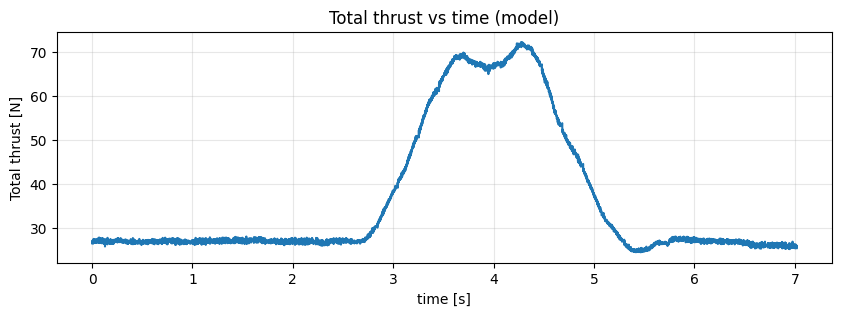

In [8]:
def thrust_from_rpm_per_motor(rpm: np.ndarray) -> np.ndarray:
    """Calibrated thrust model: T = 5.15e-8 * RPM^2 - 0.09e-3 * RPM"""
    return 5.15e-8 * rpm**2 - 0.09e-3 * rpm

rpm_avg = combined["rpm_avg"].to_numpy()
T_per_motor = thrust_from_rpm_per_motor(rpm_avg)
T_total = n_motors * T_per_motor  # sum of all four motors

combined["T_total"] = T_total

plt.figure(figsize=(10, 3))
plt.plot(t_rel, T_total)
plt.xlabel("time [s]")
plt.ylabel("Total thrust [N]")
plt.title("Total thrust vs time (model)")
plt.grid(True, alpha=0.3)
plt.show()

## 8. Compute Rotation Matrices (Body → World)

In [9]:
def R_body_to_world(qw, qx, qy, qz):
    """Quaternion (w, x, y, z) -> rotation matrix body->world."""
    return quat2mat([qw, qx, qy, qz])

R_bw_list = []
for _, row in combined.iterrows():
    R_bw = R_body_to_world(row["qw_w"], row["qx_w"], row["qy_w"], row["qz_w"])
    R_bw_list.append(R_bw)
R_bw = np.stack(R_bw_list, axis=0)  # shape (N, 3, 3)

print("✓ Rotation matrices (body->world) computed.")
print(f"   Shape: {R_bw.shape}")

✓ Rotation matrices (body->world) computed.
   Shape: (12658, 3, 3)


## 9. Measured Acceleration in World Frame

Transform IMU specific force from body to world frame:
$$\mathbf{a}_W = R_{\text{body}\to\text{world}} \cdot \mathbf{f}_b + \mathbf{g}_W$$

✓ Measured acceleration in world frame reconstructed from IMU.


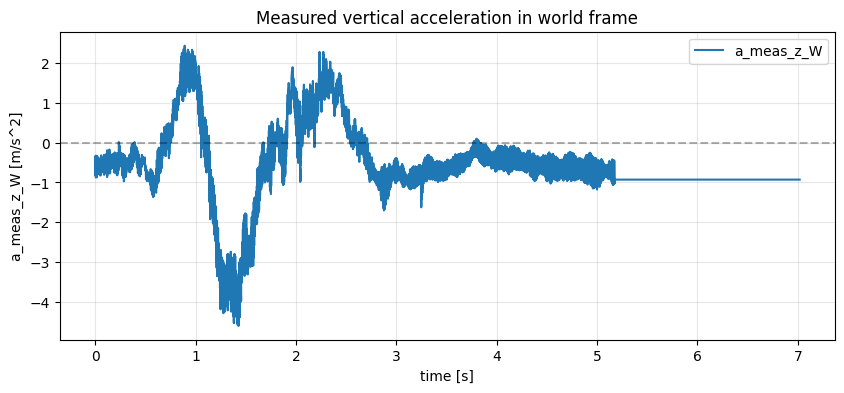

In [10]:
# IMU gives specific force f_b = a_b - g_b in body frame
# To get a_W: a_W = R_bw * f_b + g_W

g_W = np.array([0.0, 0.0, -g])

f_b = np.vstack([
    combined["ax_b"].to_numpy(),
    combined["ay_b"].to_numpy(),
    combined["az_b"].to_numpy(),
]).T  # shape (N, 3)

a_meas_W = np.einsum("nij,nj->ni", R_bw, f_b) + g_W  # shape (N,3)

combined["a_meas_x_W"] = a_meas_W[:, 0]
combined["a_meas_y_W"] = a_meas_W[:, 1]
combined["a_meas_z_W"] = a_meas_W[:, 2]

print("✓ Measured acceleration in world frame reconstructed from IMU.")

# Quick sanity plot
plt.figure(figsize=(10, 4))
plt.plot(t_rel, a_meas_W[:, 2], label="a_meas_z_W")
plt.axhline(0, color="k", linestyle="--", alpha=0.3)
plt.xlabel("time [s]")
plt.ylabel("a_meas_z_W [m/s^2]")
plt.title("Measured vertical acceleration in world frame")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

## 10. Thrust-Only Acceleration in World Frame

Compute expected acceleration if only thrust and gravity act:
$$\mathbf{a}_{\text{thrust},W} = \frac{\mathbf{F}_{\text{thrust},W}}{m} + \mathbf{g}_W$$

✓ Thrust-only acceleration in world frame computed.


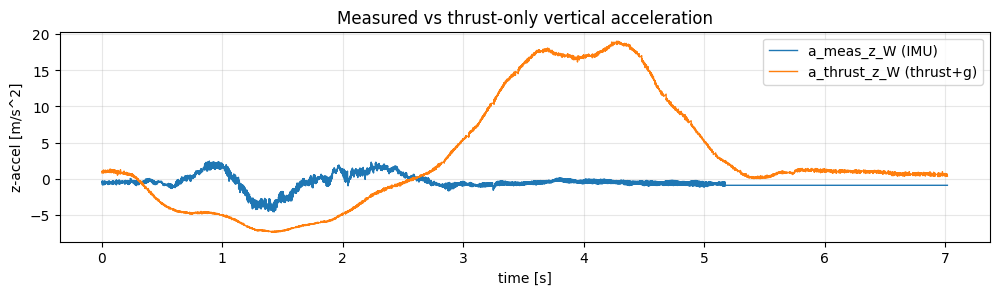

In [11]:
# Thrust vector in body frame: F_thrust_B = [0, 0, T_total]
F_thrust_B = np.zeros_like(a_meas_W)
F_thrust_B[:, 2] = T_total

# Transform to world frame: F_thrust_W = R_bw * F_thrust_B
F_thrust_W = np.einsum("nij,nj->ni", R_bw, F_thrust_B)

# Newton: m * a_W = F_thrust_W + m g_W  (if only thrust + gravity)
a_thrust_W = F_thrust_W / mass + g_W

combined["a_thrust_x_W"] = a_thrust_W[:, 0]
combined["a_thrust_y_W"] = a_thrust_W[:, 1]
combined["a_thrust_z_W"] = a_thrust_W[:, 2]

print("✓ Thrust-only acceleration in world frame computed.")

# Plot measured vs thrust-only (vertical component)
plt.figure(figsize=(12, 6))

plt.subplot(2, 1, 1)
plt.plot(t_rel, a_meas_W[:, 2], label="a_meas_z_W (IMU)", linewidth=1.0)
plt.plot(t_rel, a_thrust_W[:, 2], label="a_thrust_z_W (thrust+g)", linewidth=1.0)
plt.xlabel("time [s]")
plt.ylabel("z-accel [m/s^2]")
plt.title("Measured vs thrust-only vertical acceleration")
plt.grid(True, alpha=0.3)
plt.legend()

## 11. Aerodynamic Acceleration Residual

The difference represents aerodynamic effects:
$$\mathbf{a}_{\text{aero},W} = \mathbf{a}_{\text{meas},W} - \mathbf{a}_{\text{thrust},W} = \frac{\mathbf{F}_{\text{aero},W}}{m}$$

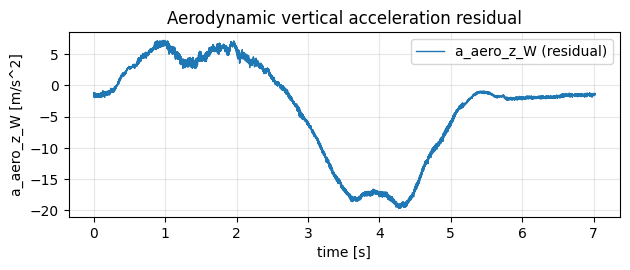

✓ Aerodynamic acceleration residual (world frame) computed.


In [12]:
a_aero_W = a_meas_W - a_thrust_W  # this is F_aero_W / m

combined["a_aero_x_W"] = a_aero_W[:, 0]
combined["a_aero_y_W"] = a_aero_W[:, 1]
combined["a_aero_z_W"] = a_aero_W[:, 2]

plt.subplot(2, 1, 2)
plt.plot(t_rel, a_aero_W[:, 2], label="a_aero_z_W (residual)", linewidth=1.0)
plt.xlabel("time [s]")
plt.ylabel("a_aero_z_W [m/s^2]")
plt.title("Aerodynamic vertical acceleration residual")
plt.grid(True, alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

print("✓ Aerodynamic acceleration residual (world frame) computed.")

## 12. Incremental Residuals (Per Time Step)

Compute per-step increments: $\Delta \mathbf{a}(k) = \mathbf{a}(k) - \mathbf{a}(k-1)$

In [13]:
dt = np.diff(t)  # time step array (N-1)
dt_mean = np.mean(dt)
print(f"Mean dt: {dt_mean*1000:.2f} ms")

# Differences (not divided by dt -> "per step" increments)
da_aero_W = np.diff(a_aero_W, axis=0)         # shape (N-1, 3)
da_thrust_W = np.diff(a_thrust_W, axis=0)     # shape (N-1, 3)

# Optionally, derivative-style versions (increment per second)
da_aero_W_dt = da_aero_W / dt[:, None]
da_thrust_W_dt = da_thrust_W / dt[:, None]

# Time for midpoints
t_mid = 0.5 * (t[1:] + t[:-1])
t_mid_rel = t_mid - t.min()

# Store metrics in dataframe
combined_mid = pd.DataFrame({
    "t": t_mid,
    "t_rel": t_mid_rel,
    "da_aero_x_W": da_aero_W[:, 0],
    "da_aero_y_W": da_aero_W[:, 1],
    "da_aero_z_W": da_aero_W[:, 2],
    "da_thrust_x_W": da_thrust_W[:, 0],
    "da_thrust_y_W": da_thrust_W[:, 1],
    "da_thrust_z_W": da_thrust_W[:, 2],
})

print("✓ Incremental acceleration residuals computed.")
print(f"   Incremental dataset rows: {len(combined_mid)}")

Mean dt: 0.55 ms
✓ Incremental acceleration residuals computed.
   Incremental dataset rows: 12657


## 13. Comparison: Aerodynamic vs Thrust Increments

Visualize the magnitude of incremental changes to assess the relative importance of aerodynamic effects.

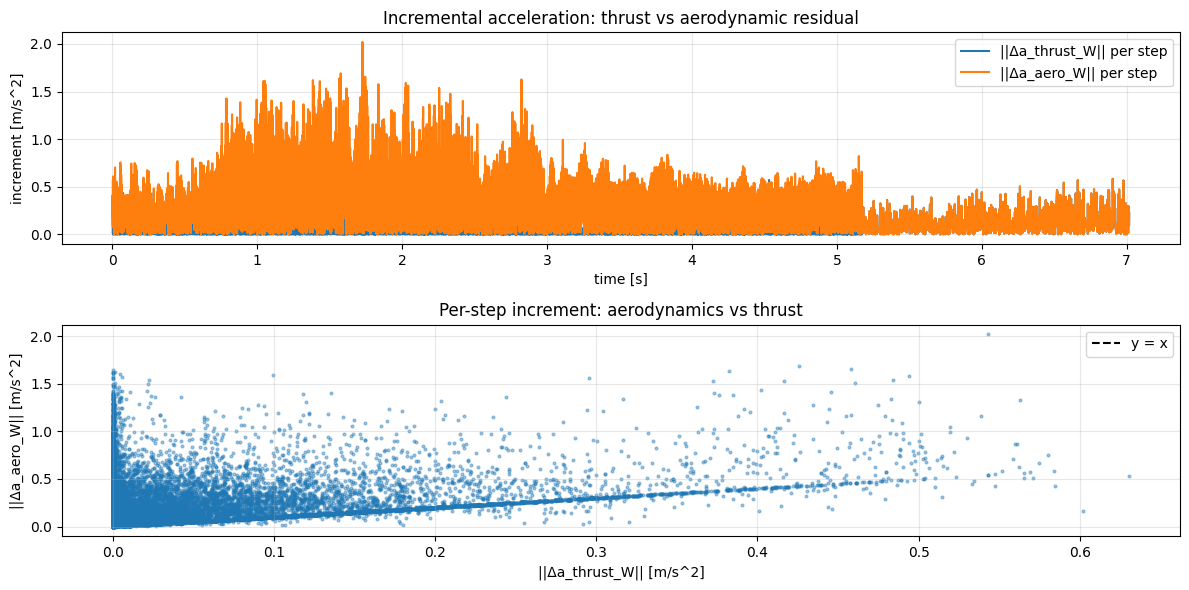

In [14]:
norm_da_aero = np.linalg.norm(da_aero_W, axis=1)
norm_da_thrust = np.linalg.norm(da_thrust_W, axis=1)

plt.figure(figsize=(12, 6))

plt.subplot(2, 1, 1)
plt.plot(t_mid_rel, norm_da_thrust, label="||Δa_thrust_W|| per step")
plt.plot(t_mid_rel, norm_da_aero, label="||Δa_aero_W|| per step")
plt.xlabel("time [s]")
plt.ylabel("increment [m/s^2]")
plt.title("Incremental acceleration: thrust vs aerodynamic residual")
plt.grid(True, alpha=0.3)
plt.legend()

plt.subplot(2, 1, 2)
plt.scatter(norm_da_thrust, norm_da_aero, s=4, alpha=0.4)
max_val = max(norm_da_thrust.max(), norm_da_aero.max())
plt.plot([0, max_val], [0, max_val], "k--", label="y = x")
plt.xlabel("||Δa_thrust_W|| [m/s^2]")
plt.ylabel("||Δa_aero_W|| [m/s^2]")
plt.title("Per-step increment: aerodynamics vs thrust")
plt.grid(True, alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

## 14. Statistics

In [15]:
ratio = norm_da_aero / (norm_da_thrust + 1e-9)

print("Increment statistics (per step):")
print(f"  mean ||Δa_aero||:   {norm_da_aero.mean():.4f} m/s^2")
print(f"  mean ||Δa_thrust||: {norm_da_thrust.mean():.4f} m/s^2")
print(f"  median ratio ||Δa_aero|| / ||Δa_thrust||: {np.median(ratio):.3f}")
print(f"  90th percentile ratio: {np.percentile(ratio, 90):.3f}")

Increment statistics (per step):
  mean ||Δa_aero||:   nan m/s^2
  mean ||Δa_thrust||: nan m/s^2
  median ratio ||Δa_aero|| / ||Δa_thrust||: nan
  90th percentile ratio: nan


## 15. Save Results

In [16]:
out_path_full = data_dir / "incremental_accel_residuals_full.csv"
out_path_mid  = data_dir / "incremental_accel_residuals_increments.csv"

combined.to_csv(out_path_full, index=False)
combined_mid.to_csv(out_path_mid, index=False)

print(f"✓ Saved full dataset with accelerations to: {out_path_full}")
print(f"✓ Saved incremental dataset to: {out_path_mid}")
print(f"  Rows (full): {len(combined)}, rows (increments): {len(combined_mid)}")

✓ Saved full dataset with accelerations to: /home/nebu/Documents/TUM/Masterarbeit/MasterTheses/logs/Circle/8mps_imu/incremental_accel_residuals_full.csv
✓ Saved incremental dataset to: /home/nebu/Documents/TUM/Masterarbeit/MasterTheses/logs/Circle/8mps_imu/incremental_accel_residuals_increments.csv
  Rows (full): 12658, rows (increments): 12657
